Enter number of cycles to analyze:  5



Cycle 1:


  Discharge Capacity (Ah):  100
  Energy Input (Wh):  400
  Energy Output (Wh):  380
  Voltage Drop during load (V):  1.5
  Constant Discharge Current (A):  20



Cycle 2:


  Discharge Capacity (Ah):  99.9
  Energy Input (Wh):  400
  Energy Output (Wh):  379
  Voltage Drop during load (V):  1.52
  Constant Discharge Current (A):  20


...


Cycle 4:


  Discharge Capacity (Ah):  99.5
  Energy Input (Wh):  400.5
  Energy Output (Wh):  376.5
  Voltage Drop during load (V):  1.58
  Constant Discharge Current (A):  20



Cycle 5:


  Discharge Capacity (Ah):  99.2
  Energy Input (Wh):  401
  Energy Output (Wh):  375
  Voltage Drop during load (V):  1.62
  Constant Discharge Current (A):  20



--- Processed Battery Data ---
   Cycle  Capacity_Fade  Efficiency  Internal_Resistance  SOH_Percentage
0      1            0.0   95.000000               0.0750           100.0
1      2            0.1   94.750000               0.0760            99.9
2      3            0.3   94.500000               0.0775            99.7
3      4            0.5   94.007491               0.0790            99.5
4      5            0.8   93.516209               0.0810            99.2


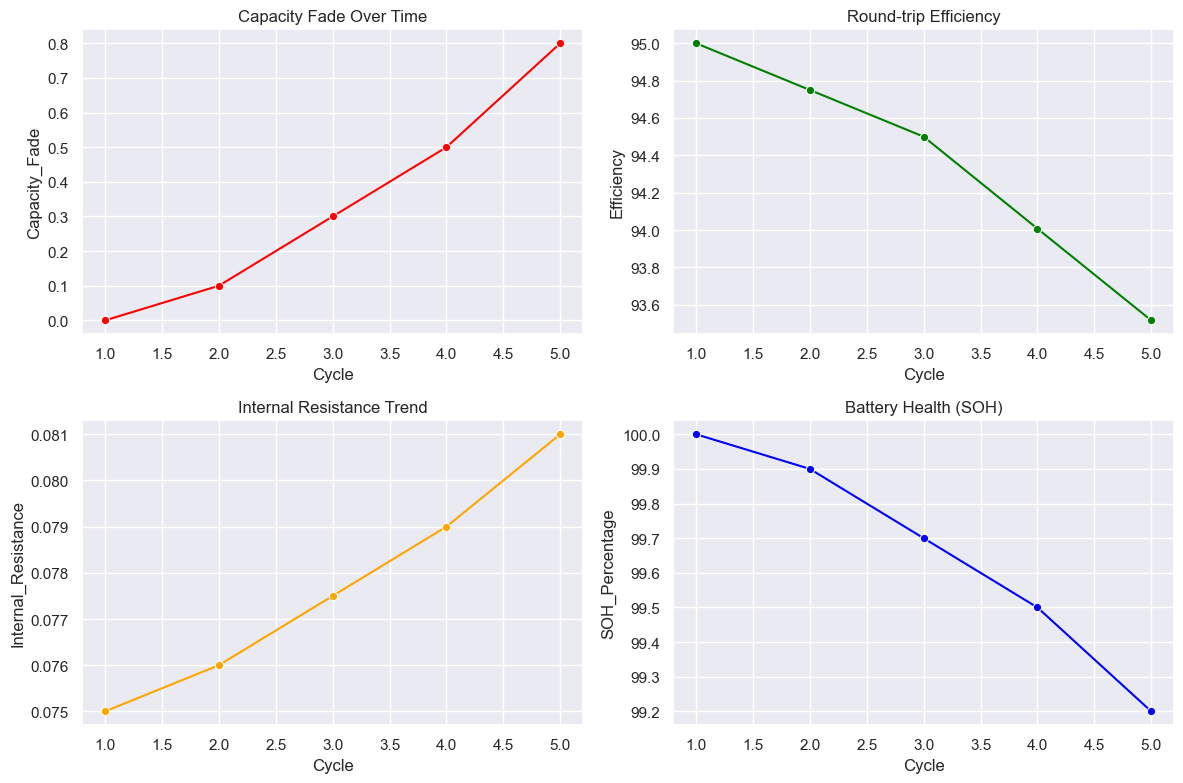

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Input
num_cycles = int(input("Enter number of cycles to analyze: "))

data = {
    'Cycle': [],
    'Discharge_Capacity': [], # Ah
    'Energy_In': [],          # Wh (Charging)
    'Energy_Out': [],         # Wh (Discharging)
    'Voltage_Drop': [],       # V
    'Current': []             # A
}

for i in range(1, num_cycles + 1):
    print(f"\nCycle {i}:")
    data['Cycle'].append(i)
    data['Discharge_Capacity'].append(float(input("  Discharge Capacity (Ah): ")))
    data['Energy_In'].append(float(input("  Energy Input (Wh): ")))
    data['Energy_Out'].append(float(input("  Energy Output (Wh): ")))
    data['Voltage_Drop'].append(float(input("  Voltage Drop during load (V): ")))
    data['Current'].append(float(input("  Constant Discharge Current (A): ")))

df = pd.DataFrame(data)

# 2. calculations
initial_capacity = df['Discharge_Capacity'].iloc[0]

# 1) capacity fade: loss of capacity
df['Capacity_Fade'] = initial_capacity - df['Discharge_Capacity']

# 2) efficiency: (energy out / energy in) * 100
df['Efficiency'] = (df['Energy_Out'] / df['Energy_In']) * 100

# 3) R = V/I
df['Internal_Resistance'] = df['Voltage_Drop'] / df['Current']

# 4) battery health (SoH): (Current Capacity / Initial Capacity) * 100
df['SOH_Percentage'] = (df['Discharge_Capacity'] / initial_capacity) * 100

print("\n--- Processed Battery Data ---")
print(df[['Cycle', 'Capacity_Fade', 'Efficiency', 'Internal_Resistance', 'SOH_Percentage']])

# 3. Visualization
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Capacity Fade Plot
sns.lineplot(ax=axes[0, 0], x='Cycle', y='Capacity_Fade', data=df, marker='o', color='red')
axes[0, 0].set_title('Capacity Fade Over Time')

# Efficiency Plot
sns.lineplot(ax=axes[0, 1], x='Cycle', y='Efficiency', data=df, marker='o', color='green')
axes[0, 1].set_title('Round-trip Efficiency')

# Internal Resistance Trend
sns.lineplot(ax=axes[1, 0], x='Cycle', y='Internal_Resistance', data=df, marker='o', color='orange')
axes[1, 0].set_title('Internal Resistance Trend')

# State of Health (SOH)
sns.lineplot(ax=axes[1, 1], x='Cycle', y='SOH_Percentage', data=df, marker='o', color='blue')
axes[1, 1].set_title('Battery Health (SOH)')

plt.tight_layout()
plt.show()